In [ ]:
import pandas as pd
import datetime as dt

In [ ]:
df = pd.read_csv("online_retail_II.csv")

In [ ]:
df.info()

In [ ]:
print(df.isnull().sum())

In [ ]:
df.columns

In [ ]:
df.dropna(subset=["Customer ID"],inplace=True)

In [ ]:
df = df[~df["Invoice"].str.contains("C", na=False)]
df = df[df["Quantity"]>0]

In [ ]:
df["TotalPrice"] = df["Price"] * df["Quantity"]

In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
total_unique_products = len(df.groupby("Description"))
print(total_unique_products)

In [ ]:
top_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).iloc[:10]
print("en çok alınan ürünler")
print(top_products)

In [ ]:
top_countries_revenue = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False).iloc[:10]
print(top_countries_revenue)

In [ ]:
freq = df.groupby("Customer ID")["Invoice"].nunique()
print(freq)

In [ ]:
money= df.groupby("Customer ID")["TotalPrice"].sum()
print(money)

In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
today_date = df['InvoiceDate'].max() + dt.timedelta(days=2)
rec = df.groupby("Customer ID")["InvoiceDate"].max().apply(lambda x: (today_date - x).days)

In [ ]:
rfm = pd.concat([rec, freq, money], axis=1)
rfm.columns = ["Recency", "Frequency", "Monetary"]
print(rfm)

In [ ]:
rfm["RecencyScore"] = pd.qcut(rfm["Recency"],5,labels=[5,4,3,2,1])
rfm["FrequencyScore"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])
rfm["MonetaryScore"] = pd.qcut(rfm["Monetary"],5,labels=[1,2,3,4,5])
rfm["RFM_SCORE"] = (rfm["RecencyScore"].astype(str)+
                    rfm["FrequencyScore"].astype(str)+
                    rfm["MonetaryScore"].astype(str))

In [ ]:
seg_map = {
    r'[1-2][1-2]':'Hibernating',
    r'[1-2][3-4]':'At_Risk',
    r'[1-2]5':'Cant_Loose',
    r'3[1-2]':'About_to_Sleep',
    r'33':'Need_Attention',
    r'[3-4][4-5]':'Loyal_Customers',
    r'41':'Promising',
    r'51':'New_Customers',
    r'[4-5][2-3]':'Potential_Loyalists',
    r'5[4-5]':'Champions'
}
rfm
rfm['Segment'] = rfm['RecencyScore'].astype(str) + rfm['FrequencyScore'].astype(str)
rfm['Segment'] = rfm['Segment'].replace(seg_map,regex=True)
df[["Customer ID"]].nunique()
rfm[["Segment","Recency","Frequency","Monetary"]].groupby("Segment").agg(["mean","count"])
print(len(rfm['Segment']))

In [ ]:
from matplotlib import pyplot as plt

In [ ]:
x_top_products= top_products.index
y_top_products = top_products.values

array([109169,  93640,  80995,  79913,  77916,  75759,  71129,  55270,
        53495,  46107])

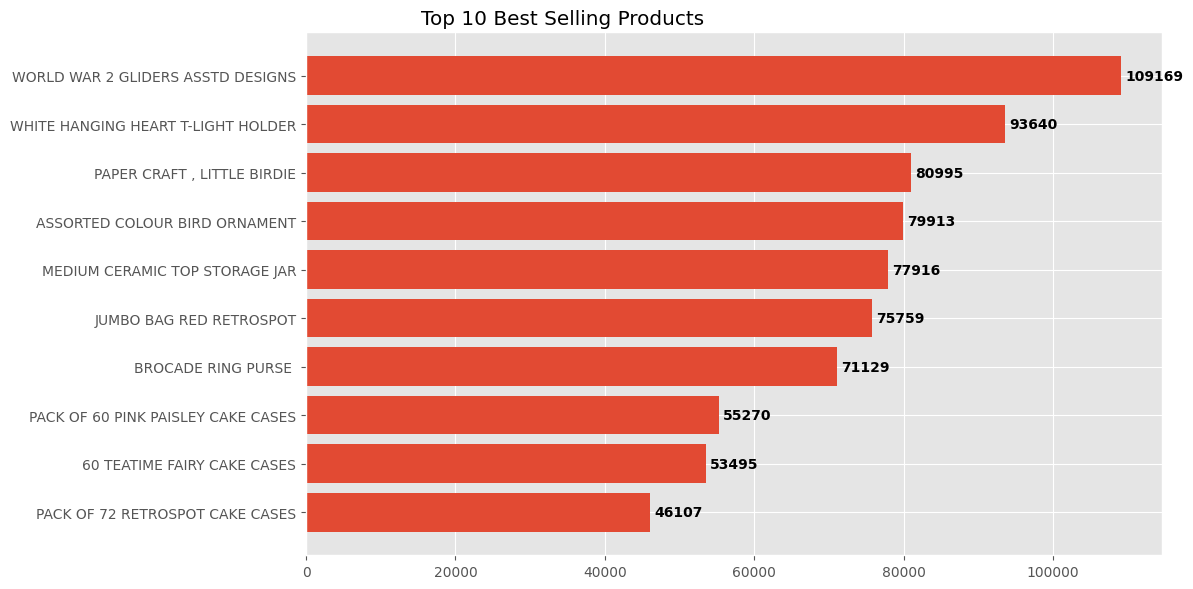

In [ ]:
plt.style.use('ggplot')
plt.figure(figsize=(12,6))
a = plt.barh(x_top_products, y_top_products, color="#BE320C")
plt.bar_label(a, padding=3, fontweight='bold')
plt.title("Top 10 Best Selling Products", x=0.3)
plt.tight_layout()
plt.gca().invert_yaxis()
plt.savefig("Top 10 Best Selling Products.png")
plt.show()

In [ ]:
x_top_countries_revenue = top_countries_revenue.index
y_top_countries_revenue = top_countries_revenue.values

In [ ]:
for i, (country, total_price) in enumerate(zip(top_countries_revenue.index, top_countries_revenue.values)):
    plt.text(total_price, i, f'  £{total_price/1000000:.2f}M', 
             va='center', fontsize=10, fontweight='bold', color='black')
plt.style.use("ggplot")
plt.barh(x_top_countries_revenue,y_top_countries_revenue)
plt.title("Total Revenue by Country (Top 10)",fontweight='bold',x=0.4)
plt.xlabel('Revenue (£)', fontsize=12, fontweight='bold')
plt.ylabel('Country', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.gca().invert_yaxis()
plt.savefig("Total Revenue by Country (Top 10).png")
plt.show()


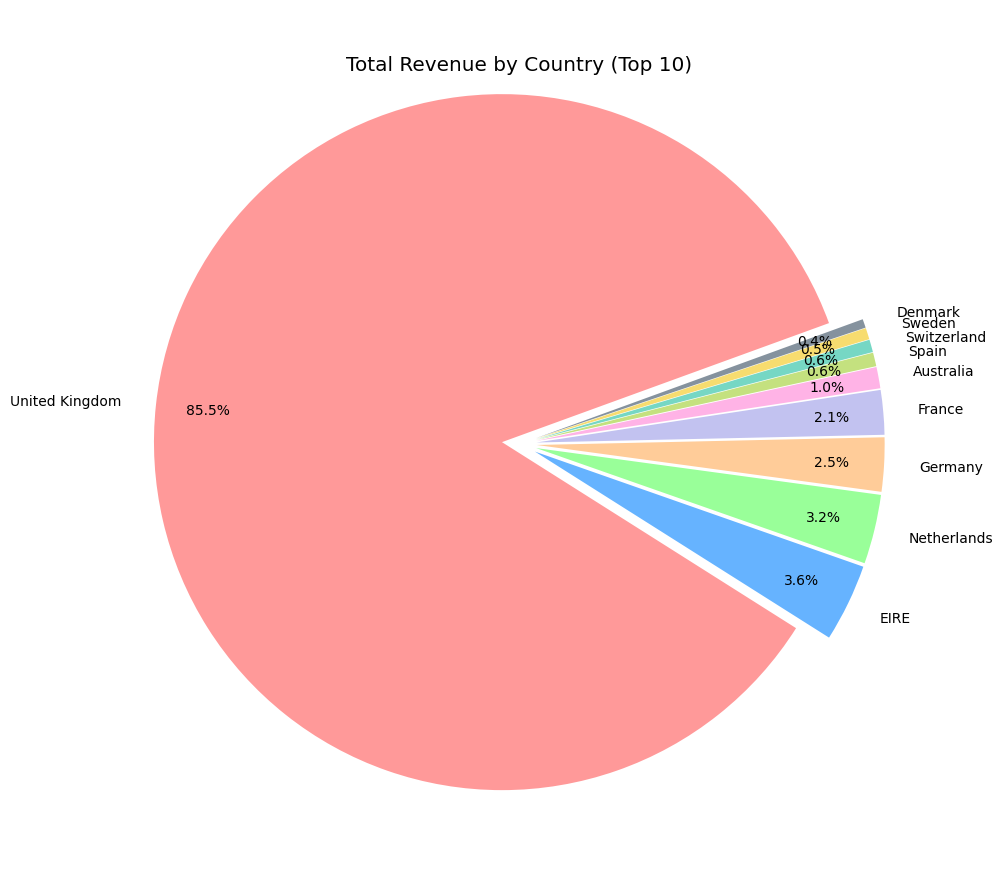

In [59]:
explode = [0.05] * 10
plt.figure(figsize=(12, 9))
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99', '#c2c2f0',
          '#ffb3e6', '#c4e17f', '#76D7C4', '#F7DC6F', '#85929E']
plt.style.use("ggplot")
plt.pie(y_top_countries_revenue,labels=x_top_countries_revenue,explode=explode,colors=colors,startangle=20,pctdistance=0.85,autopct="%1.1f%%")
plt.tight_layout()
plt.title("Total Revenue by Country (Top 10)",y=0.92)
plt.savefig("pie Total Revenue by Country (Top 10).png")
plt.show()


In [31]:
segment = rfm["Segment"].value_counts()

In [32]:
x_segments= segment.index
y_customer_counts = segment.values

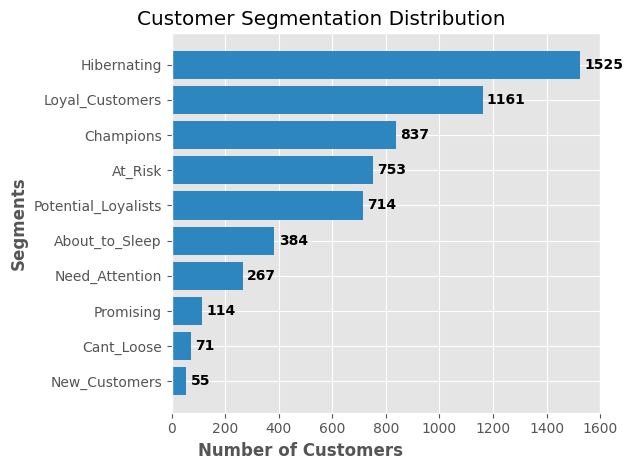

In [ ]:
plt.figure(figsize=(12,6))
bars = plt.barh(x_segments, y_customer_counts, color='#2E86C1')
plt.title("Customer Segmentation Distribution",x=0.35)
plt.xlabel("Number of Customers", fontsize=12, fontweight='bold',x=0.3)
plt.ylabel("Segments", fontsize=12, fontweight='bold')
plt.bar_label(bars, padding=3, fontweight='bold')
plt.tight_layout()
plt.gca().invert_yaxis()
plt.savefig("Customer Segmentation Distribution.png")
plt.show()